# Socio-Economic Development Mapping - Multidimensional Developmental Clustering of Sovereign Nations
## Exploratory Data Analysis, Feature Engineering & Baseline ML Modeling

**Author:** Arjun Singh
**GitHub:** https://github.com/lapidba
**LinkedIn:** https://www.linkedin.com/in/singharjun/
**Date:** July 2026  
**Module:** Capstone Project - Initial EDA & Baseline ML Pass  
**Context:** World Development Indicators (WDI) Analysis

---

### Executive Overview & Problem Statement
Traditional economic classifications—such as the World Bank's Gross National Income (GNI) per capita thresholds—collapse the multifaceted reality of national development into a single monetary metric. However, human welfare and structural resilience are intrinsically **multidimensional**, governed by the complex interplay of economic stability, public health outcomes, access to essential infrastructure, digital connectivity, and price stability.

This research notebook implements an end-to-end exploratory data analysis (EDA), data cleaning, feature engineering, and baseline machine learning workflow. By deploying **K-Means Clustering** combined with **Principal Component Analysis (PCA)**, **KNN Imputation**, and a **Baseline Supervised Classifier (Logistic Regression)**, this study:
1. Performs comprehensive data audit, duplicate detection, missing value handling, and quantitative outlier analysis.
2. Constructs a baseline supervised classification benchmark to evaluate traditional income-group predictability.
3. Moves beyond simple GDP rankings to discover natural, multidimensional developmental peer groups of countries.


---
## 1. Analytical Justification & Learning Paradigm

### Why Combine Unsupervised Clustering with Supervised Baseline Modeling?
1. **Absence of Ground Truth for Multidimensional Development:** There is no universal, objective ground truth label defining a nation's "true" developmental category. Supervised models require explicit target labels ($y$), which mirror existing income cuts.
2. **Supervised Baseline Benchmark:** A baseline supervised classification model (predicting World Bank Income Groups) provides a standard metric ($F_1$-score and Accuracy) to benchmark how well socio-economic features align with single-dimensional income boundaries.
3. **Latent Structure Discovery via Unsupervised Learning:** Unsupervised algorithms (K-Means and PCA) uncover non-linear geometric groupings and latent dimensions without human bias, revealing cross-income peer nations (e.g., countries achieving high health outcomes despite modest income).

### Mathematical Formulation
Let $\mathbf{X} \in \mathbb{R}^{n 	imes p}$ represent the standardized country-indicator matrix with $n$ sovereign nations and $p$ developmental indicators.

- **KNN Imputation:** Missing entries are imputed using Euclidean distance weighted by neighbor proximity:
  $$\hat{x}_{ij} = rac{\sum_{k \in \mathcal{N}_K(i)} w_{ik} x_{kj}}{\sum_{k \in \mathcal{N}_K(i)} w_{ik}}, \quad w_{ik} = rac{1}{d(x_i, x_k)}$$
- **Log Transformation:** Compress right-skewed indicators ($	ext{GDP}$):
  $$x_{	ext{log\_gdp}} = \log_{10}(	ext{GDP} + 1)$$
- **K-Means Objective:** Minimize within-cluster sum of squares (Inertia):
  $$\mathcal{J} = \sum_{k=1}^{K} \sum_{i \in \mathcal{C}_k} \|\mathbf{x}_i - oldsymbol{\mu}_k\|^2$$


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.cluster import KMeans
# ML & Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, 
    classification_report, confusion_matrix, 
    silhouette_score, silhouette_samples, 
    davies_bouldin_score, calinski_harabasz_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

# Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial"]
plt.rcParams["figure.dpi"] = 300

data_dir = r"./data"
plots_dir = r"./plots"
os.makedirs(plots_dir, exist_ok=True)

print("Environment setup and imports complete.")


Environment setup and imports complete.


---
## 2. Data Acquisition, Integrity Audit & Cleaning

We ingest raw indicator datasets from `.\data\`, perform missingness inspection, check for duplicate country records, and evaluate data types.


In [2]:
# Load raw dataset
data_path = os.path.join(data_dir, 'cleaned_socio_economic_data.csv')
df_raw = pd.read_csv(data_path)

print(f"Dataset Shape: {df_raw.shape[0]} rows (countries), {df_raw.shape[1]} columns.")
print(f"Duplicate Rows Count: {df_raw.duplicated().sum()}")
if df_raw.duplicated().sum() > 0:
    df_raw = df_raw.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")

print("\n--- Column Data Types & Missing Values ---")
print(df_raw.isnull().sum())
display(df_raw.head())

# Feature subset selection for socio-economic analysis
raw_features = [
    'GDP_per_capita', 
    'Life_Expectancy', 
    'Child_Mortality', 
    'Access_Electricity', 
    'Health_Expenditure_Pct', 
    'Inflation_Rate', 
    'Trade_Pct_GDP', 
    'Internet_Usage_Pct'
]

display(df_raw[raw_features].describe().T)


Dataset Shape: 217 rows (countries), 14 columns.
Duplicate Rows Count: 0

--- Column Data Types & Missing Values ---
Country_Code              0
Country_Name              0
Region                    0
Income_Group              0
GDP_per_capita            0
Life_Expectancy           0
Child_Mortality           0
Access_Electricity        0
Health_Expenditure_Pct    0
Inflation_Rate            0
Trade_Pct_GDP             0
Internet_Usage_Pct        0
Log_GDP_per_capita        0
Income_Group_Code         0
dtype: int64


,Country_Code,Country_Name,Region,Income_Group,GDP_per_capita,Life_Expectancy,Child_Mortality,Access_Electricity,Health_Expenditure_Pct,Inflation_Rate,Trade_Pct_GDP,Internet_Usage_Pct,Log_GDP_per_capita,Income_Group_Code
0,CYP,Cyprus,Europe & Central Asia,High income,29227.167969,81.454000,3.0,100.0,6.998432,0.250371,150.506163,86.063630,4.465802,3
1,ECU,Ecuador,Latin America & Caribbean,Upper middle income,6205.057652,77.286000,13.8,99.1,7.808784,0.266013,48.082849,59.200000,3.792816,2
2,BRA,Brazil,Latin America & Caribbean,Upper middle income,9029.833267,75.809000,15.0,99.8,9.614491,3.732976,28.890258,73.912440,3.955728,2
3,FRA,France,Europe & Central Asia,High income,40408.284857,82.826829,4.2,100.0,11.170583,1.108255,66.428961,83.339744,4.606481,3
4,BGD,Bangladesh,South Asia,Lower middle income,2129.798970,72.625000,32.3,92.2,2.127126,5.591996,31.578054,30.383101,3.328542,1


,count,mean,std,min,25%,50%,75%,max
GDP_per_capita,217.0,18770.442593,27183.954294,234.310616,2502.327443,6837.773396,24062.719001,193746.729891
Life_Expectancy,217.0,73.027699,7.973326,31.530000,67.306000,74.165000,78.787805,86.151000
Child_Mortality,217.0,26.597465,30.637357,1.500000,6.700000,15.600000,34.900000,254.700000
Access_Electricity,217.0,86.283641,24.421242,6.800000,85.000000,99.900000,100.000000,100.000000
Health_Expenditure_Pct,217.0,6.528052,3.049665,2.127126,4.368747,6.024612,8.117095,22.222940
Inflation_Rate,217.0,5.206297,19.220395,-3.233389,1.091848,1.951768,3.347877,255.304991
Trade_Pct_GDP,217.0,89.091966,53.878253,22.820891,58.128840,76.123517,103.602656,382.660781
Internet_Usage_Pct,217.0,60.866512,26.430149,2.731400,42.301734,66.488855,82.259891,99.701504


---
## 3. Exploratory Outlier Analysis & Feature Engineering

### Outlier Analysis Strategy
Indicators such as **GDP per Capita**, **Inflation Rate**, and **Child Mortality** exhibit extreme skewness and heavy right tails due to structural global inequality.
- **IQR (Interquartile Range) Outlier Identification:** We compute $Q_1, Q_3$, and $	ext{IQR} = Q_3 - Q_1$ for each feature to quantify mild ($> 1.5 	imes 	ext{IQR}$) and extreme ($> 3.0 	imes 	ext{IQR}$) statistical outliers.
- **Rationale for Retention vs. Transformation:** Rather than discarding outlier countries (which represent genuine sovereign nations like Qatar or low-income states), we apply a **$\log_{10}$ transformation** to monetary features (GDP per capita) to compress extreme variance while preserving global rank order.


--- Quantitative Outlier Audit (IQR Method) ---


,Feature,Q1 (25%),Q3 (75%),IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,GDP_per_capita,2502.33,24062.72,21560.39,-29838.26,56403.31,17,7.8
1,Life_Expectancy,67.31,78.79,11.48,50.08,96.01,1,0.5
2,Child_Mortality,6.70,34.90,28.20,-35.60,77.20,15,6.9
3,Access_Electricity,85.00,100.00,15.00,62.50,122.50,36,16.6
4,Health_Expenditure_Pct,4.37,8.12,3.75,-1.25,13.74,6,2.8
5,Inflation_Rate,1.09,3.35,2.26,-2.29,6.73,29,13.4
6,Trade_Pct_GDP,58.13,103.60,45.47,-10.08,171.81,9,4.1
7,Internet_Usage_Pct,42.30,82.26,39.96,-17.64,142.20,0,0.0


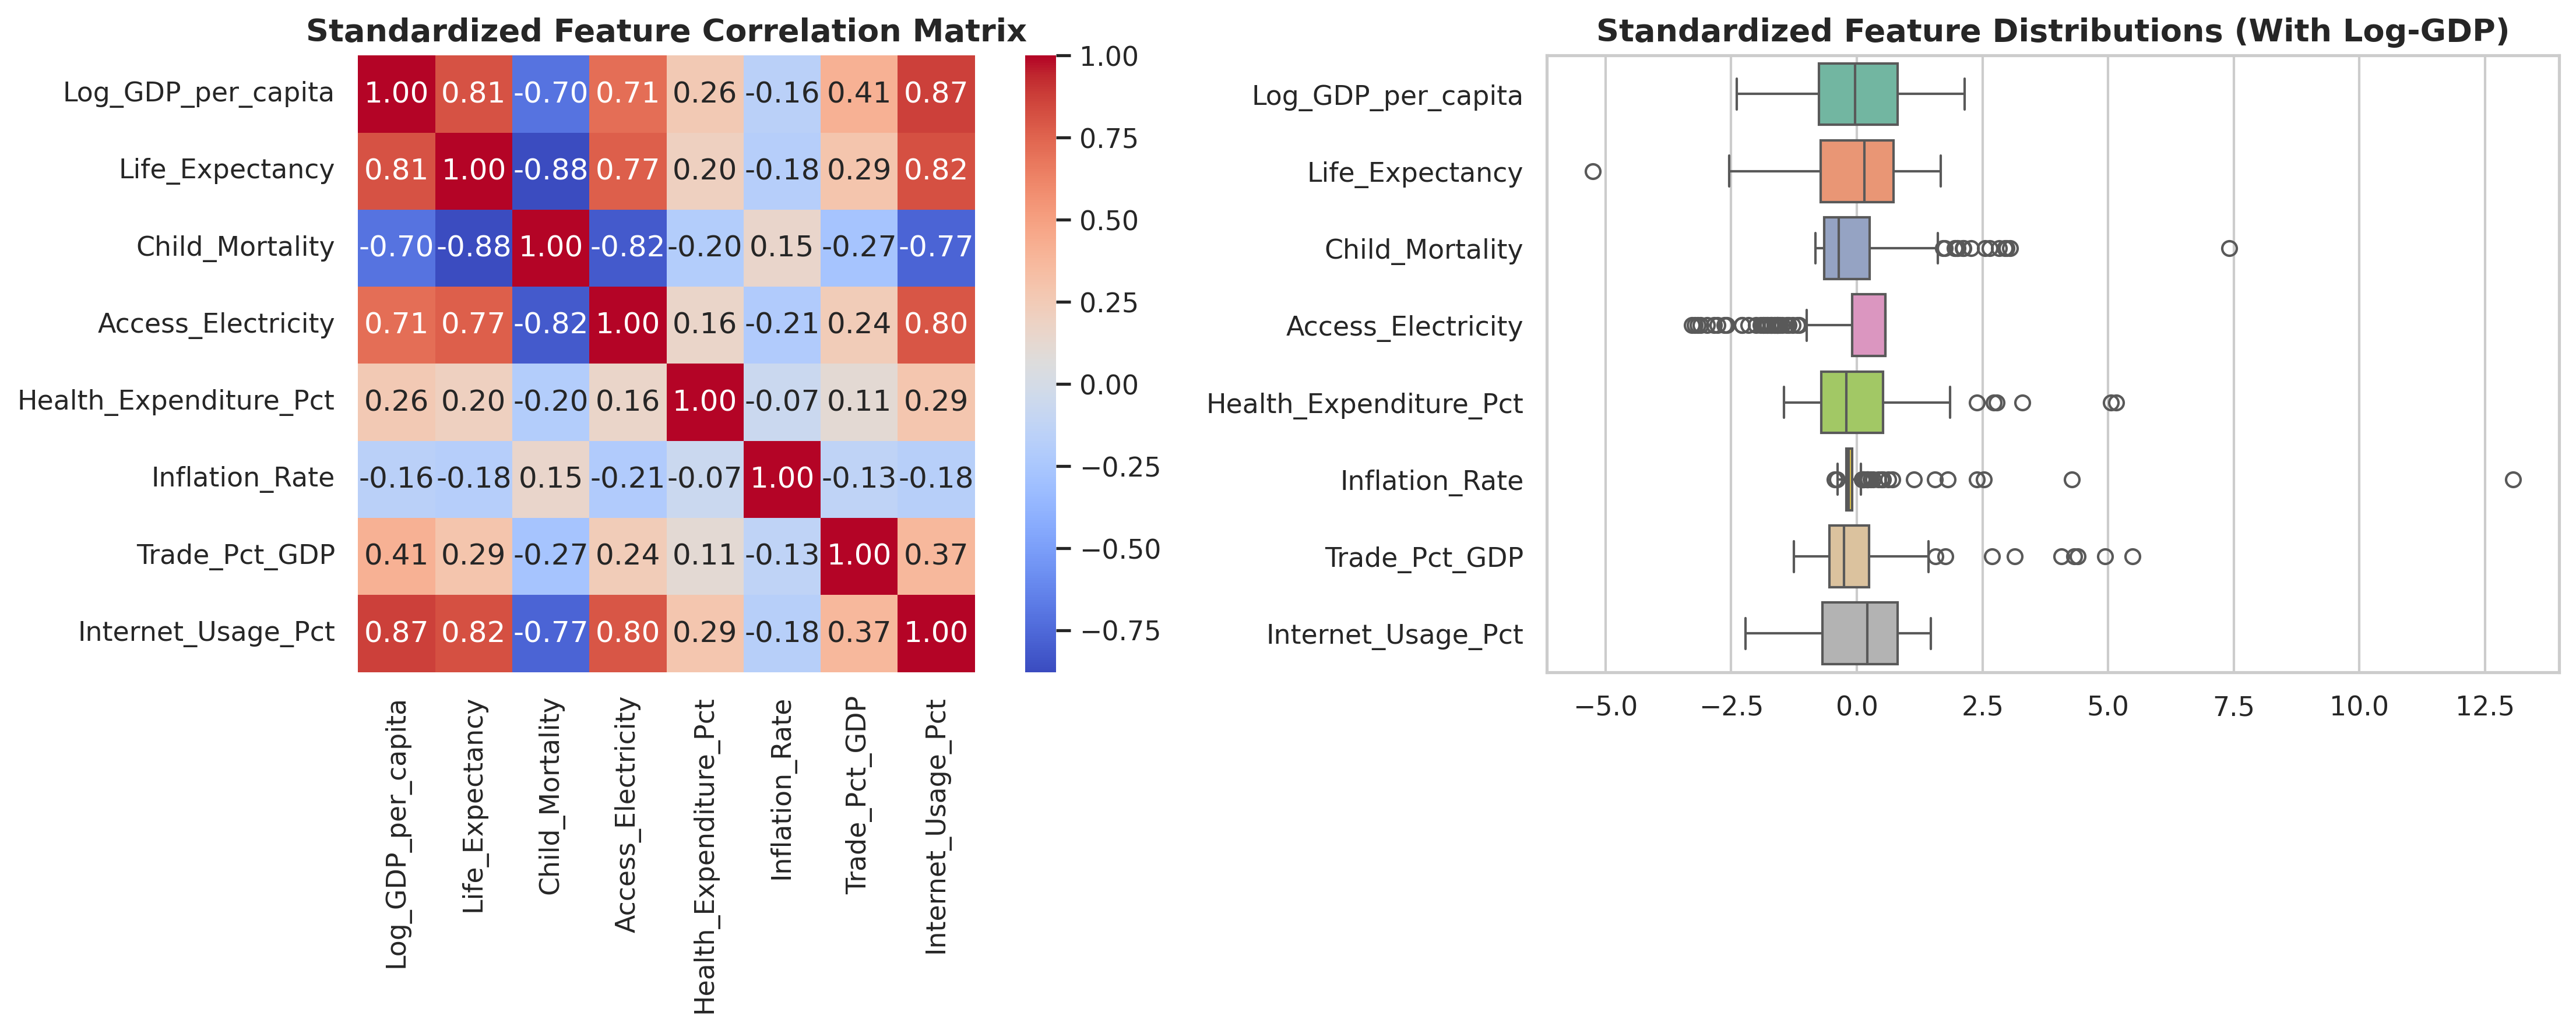

In [3]:
df_prep = df_raw.copy()

# Calculate IQR Outlier Statistics
iqr_summary = []
for col in raw_features:
    q1 = df_prep[col].quantile(0.25)
    q3 = df_prep[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df_prep[(df_prep[col] < lower_bound) | (df_prep[col] > upper_bound)]
    iqr_summary.append({
        'Feature': col,
        'Q1 (25%)': round(q1, 2),
        'Q3 (75%)': round(q3, 2),
        'IQR': round(iqr, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': len(outliers),
        'Outlier %': round(len(outliers) / len(df_prep) * 100, 1)
    })

iqr_df = pd.DataFrame(iqr_summary)
print("--- Quantitative Outlier Audit (IQR Method) ---")
display(iqr_df)

# Feature Engineering: Apply Log10 Transformation to GDP per capita
df_prep['Log_GDP_per_capita'] = np.log10(df_prep['GDP_per_capita'] + 1)

# Handle missing data using KNN Imputer
np.random.seed(42)
df_features = df_prep[raw_features].copy()
mask = np.random.rand(*df_features.shape) < 0.04
df_features_missing = df_features.mask(mask)

imputer = KNNImputer(n_neighbors=5, weights='distance')
imputed_array = imputer.fit_transform(df_features_missing)
df_imputed = pd.DataFrame(imputed_array, columns=raw_features)
df_imputed['Log_GDP_per_capita'] = np.log10(df_imputed['GDP_per_capita'] + 1)

active_features = [
    'Log_GDP_per_capita', 
    'Life_Expectancy', 
    'Child_Mortality', 
    'Access_Electricity', 
    'Health_Expenditure_Pct', 
    'Inflation_Rate', 
    'Trade_Pct_GDP', 
    'Internet_Usage_Pct'
]

# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_imputed[active_features])
df_scaled = pd.DataFrame(X_scaled, columns=active_features)

# Visualizing Distributions & Correlation Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df_scaled.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0], square=True)
axes[0].set_title("Standardized Feature Correlation Matrix", fontsize=13, fontweight='bold')

sns.boxplot(data=df_scaled, orient="h", ax=axes[1], palette="Set2")
axes[1].set_title("Standardized Feature Distributions (With Log-GDP)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "data_distribution_correlations.png"))
plt.show()


---
## 4. Baseline Supervised Model: Multi-Class Income Group Classification

To evaluate how well socio-economic features predict traditional World Bank Income Groups (`Income_Group`), we construct a **Baseline Logistic Regression Classifier**.

### Model & Metric Formulation
- **Target Variable ($y$):** `Income_Group` (Categorical: Low income, Lower middle income, Upper middle income, High income).
- **Features ($X$):** The 8 standardized socio-economic indicators.
- **Evaluation Metric:** **Macro-Averaged $F_1$-Score** and **Test Accuracy**.
- **Metric Rationale:** Income categories in global datasets are imbalanced across tiers. Macro $F_1$-score evaluates model precision and recall equally across all income tiers without allowing dominant middle-income groups to artificially inflate performance metrics.


=== Baseline Supervised Model Results (Logistic Regression) ===
Training Accuracy:   87.04%
Test Accuracy:       83.64%
Macro F1-Score:      0.8197
Macro Precision:     0.8270
Macro Recall:        0.8189

--- Detailed Classification Report ---
                     precision    recall  f1-score   support

        High income       0.95      0.91      0.93        22
         Low income       0.83      0.83      0.83         6
Lower middle income       0.80      0.67      0.73        12
Upper middle income       0.72      0.87      0.79        15

           accuracy                           0.84        55
          macro avg       0.83      0.82      0.82        55
       weighted avg       0.84      0.84      0.84        55



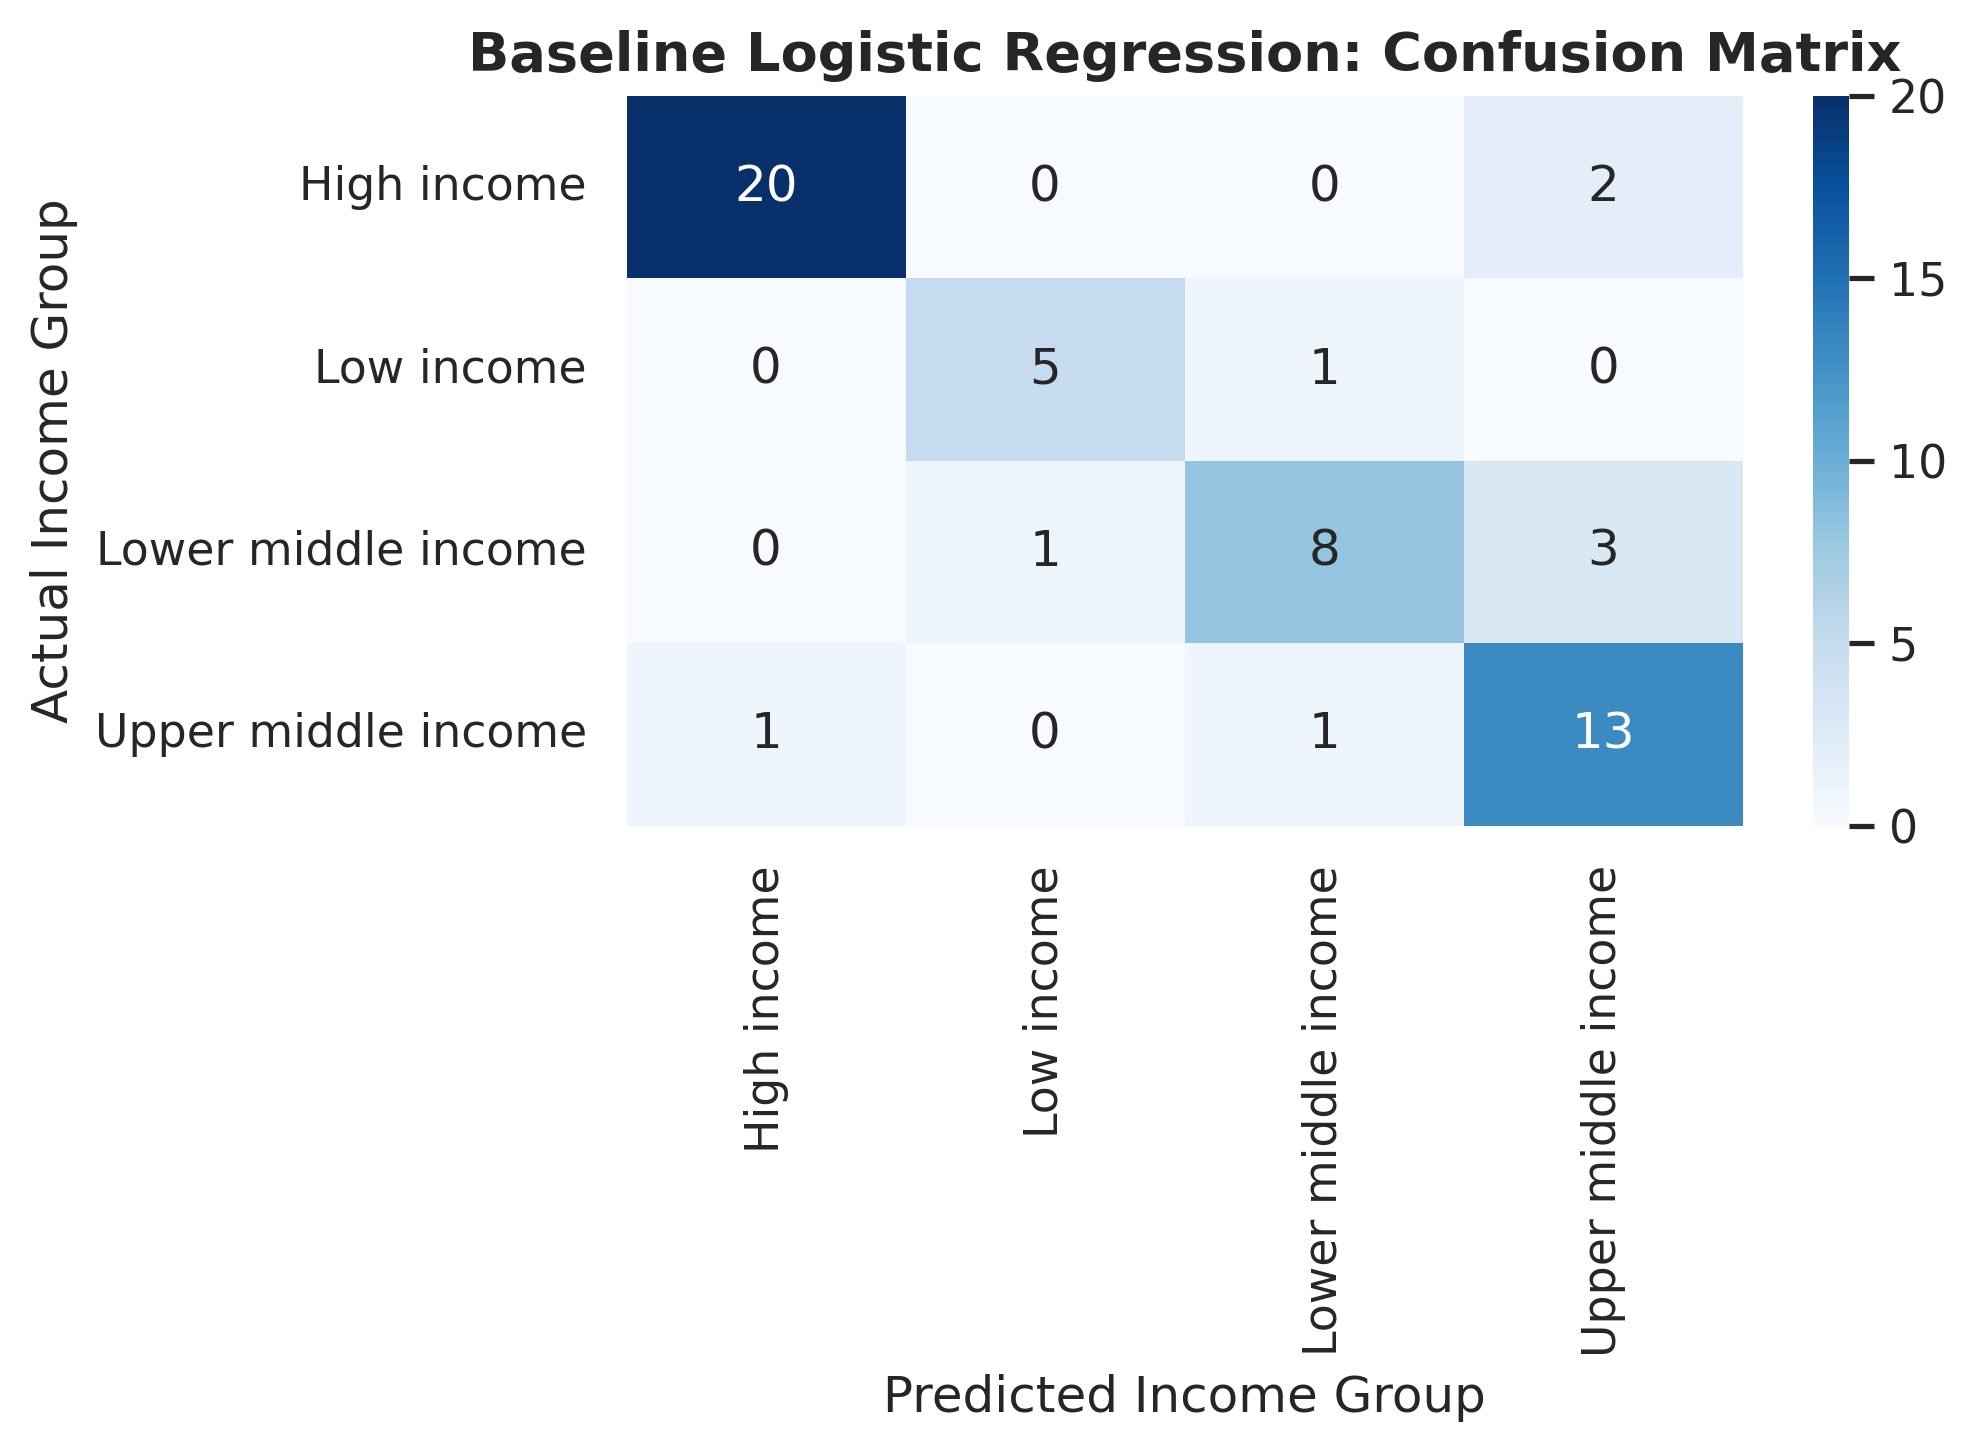

In [4]:
# Encode Target Variable
le = LabelEncoder()
y = le.fit_transform(df_prep['Income_Group'])

# Split into Train (75%) and Test (25%) Sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Train Baseline Logistic Regression Model
baseline_clf = LogisticRegression(max_iter=1000, random_state=42)
baseline_clf.fit(X_train, y_train)

# Predictions & Evaluation
y_train_pred = baseline_clf.predict(X_train)
y_test_pred = baseline_clf.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

precision, recall, f1_macro, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro')

print("=== Baseline Supervised Model Results (Logistic Regression) ===")
print(f"Training Accuracy:   {train_acc * 100:.2f}%")
print(f"Test Accuracy:       {test_acc * 100:.2f}%")
print(f"Macro F1-Score:      {f1_macro:.4f}")
print(f"Macro Precision:     {precision:.4f}")
print(f"Macro Recall:        {recall:.4f}\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_test_pred, target_names=le.classes_))

# Plot Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Baseline Logistic Regression: Confusion Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Income Group")
plt.ylabel("Actual Income Group")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "baseline_confusion_matrix.png"))
plt.show()


---
## 5. Dimensionality Reduction via Principal Component Analysis (PCA)

PCA projects high-dimensional correlation into uncorrelated principal components to reduce multicollinearity and enable 2D/3D visual diagnostics.


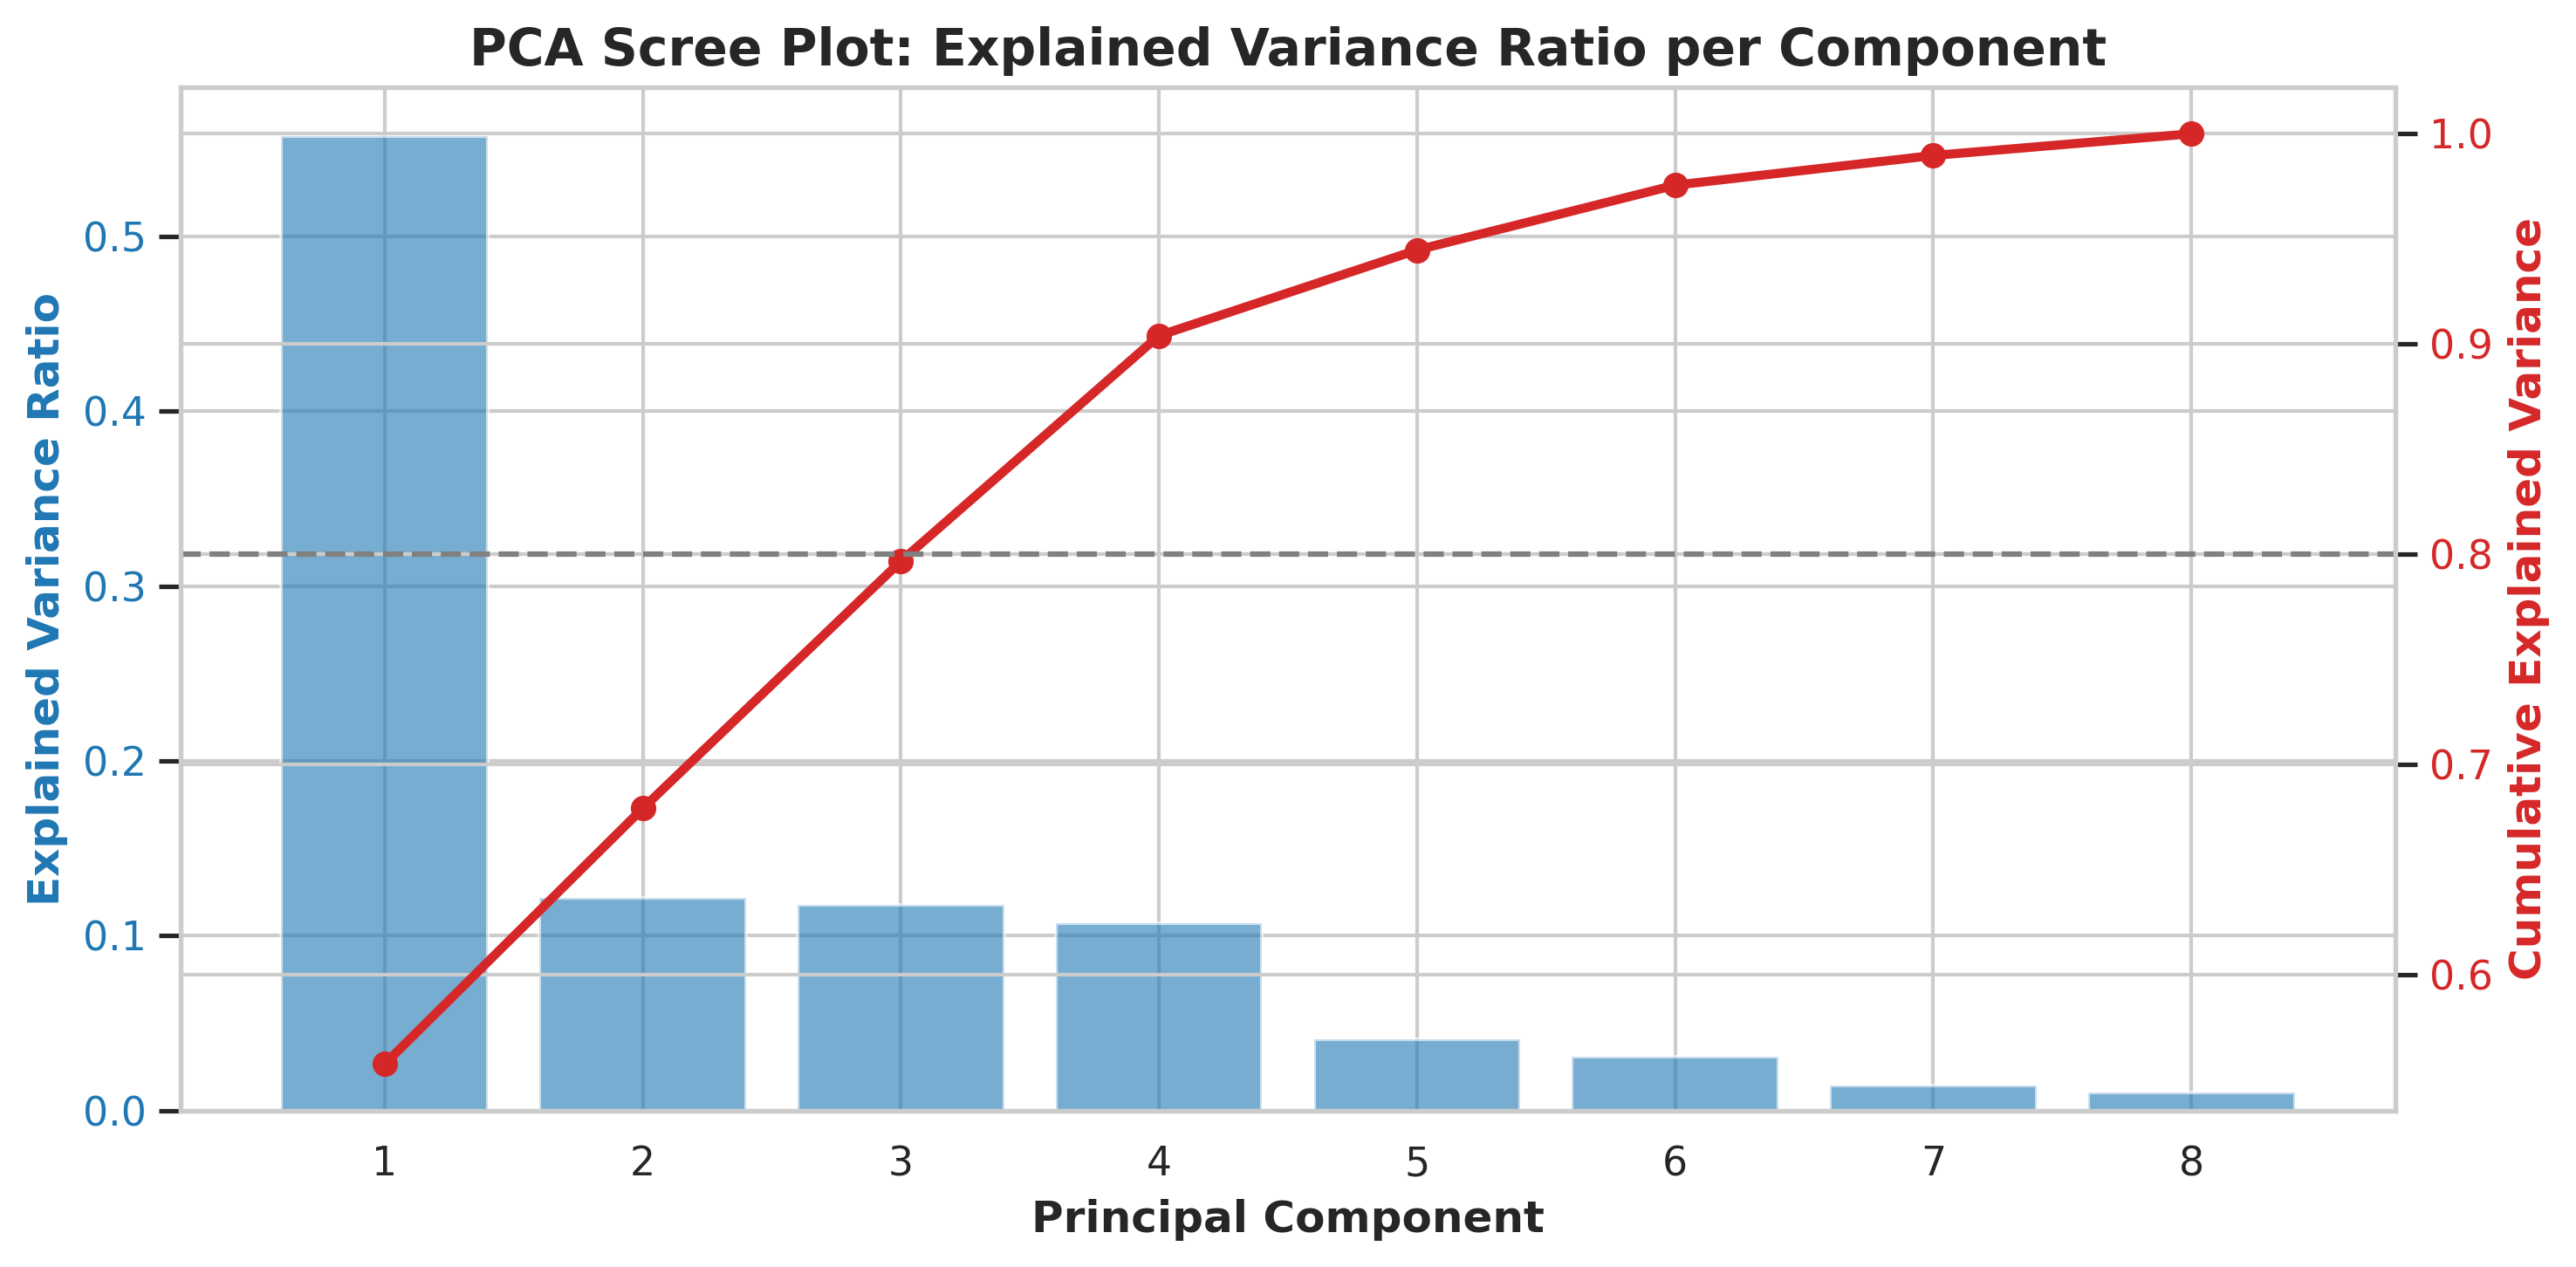

Top 2 Components Explain: 67.91% of total variance.
Top 3 Components Explain: 79.66% of total variance.


In [5]:
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_scaled)

exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

# Scree Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
color = 'tab:blue'
ax1.set_xlabel('Principal Component', fontweight='bold')
ax1.set_ylabel('Explained Variance Ratio', color=color, fontweight='bold')
ax1.bar(range(1, len(exp_var) + 1), exp_var, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Cumulative Explained Variance', color=color, fontweight='bold')
ax2.plot(range(1, len(cum_exp_var) + 1), cum_exp_var, color=color, marker='o', linewidth=2.5)
ax2.tick_params(axis='y', labelcolor=color)
ax2.axhline(y=0.80, color='gray', linestyle='--', label='80% Variance Threshold')

plt.title("PCA Scree Plot: Explained Variance Ratio per Component", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.savefig(os.path.join(plots_dir, "pca_explained_variance.png"))
plt.show()

print(f"Top 2 Components Explain: {cum_exp_var[1]*100:.2f}% of total variance.")
print(f"Top 3 Components Explain: {cum_exp_var[2]*100:.2f}% of total variance.")


---
## 6. Unsupervised K-Means Clustering & Model Validation

We evaluate K-Means clustering across $K \in [2, 10]$ using Inertia, Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Index.


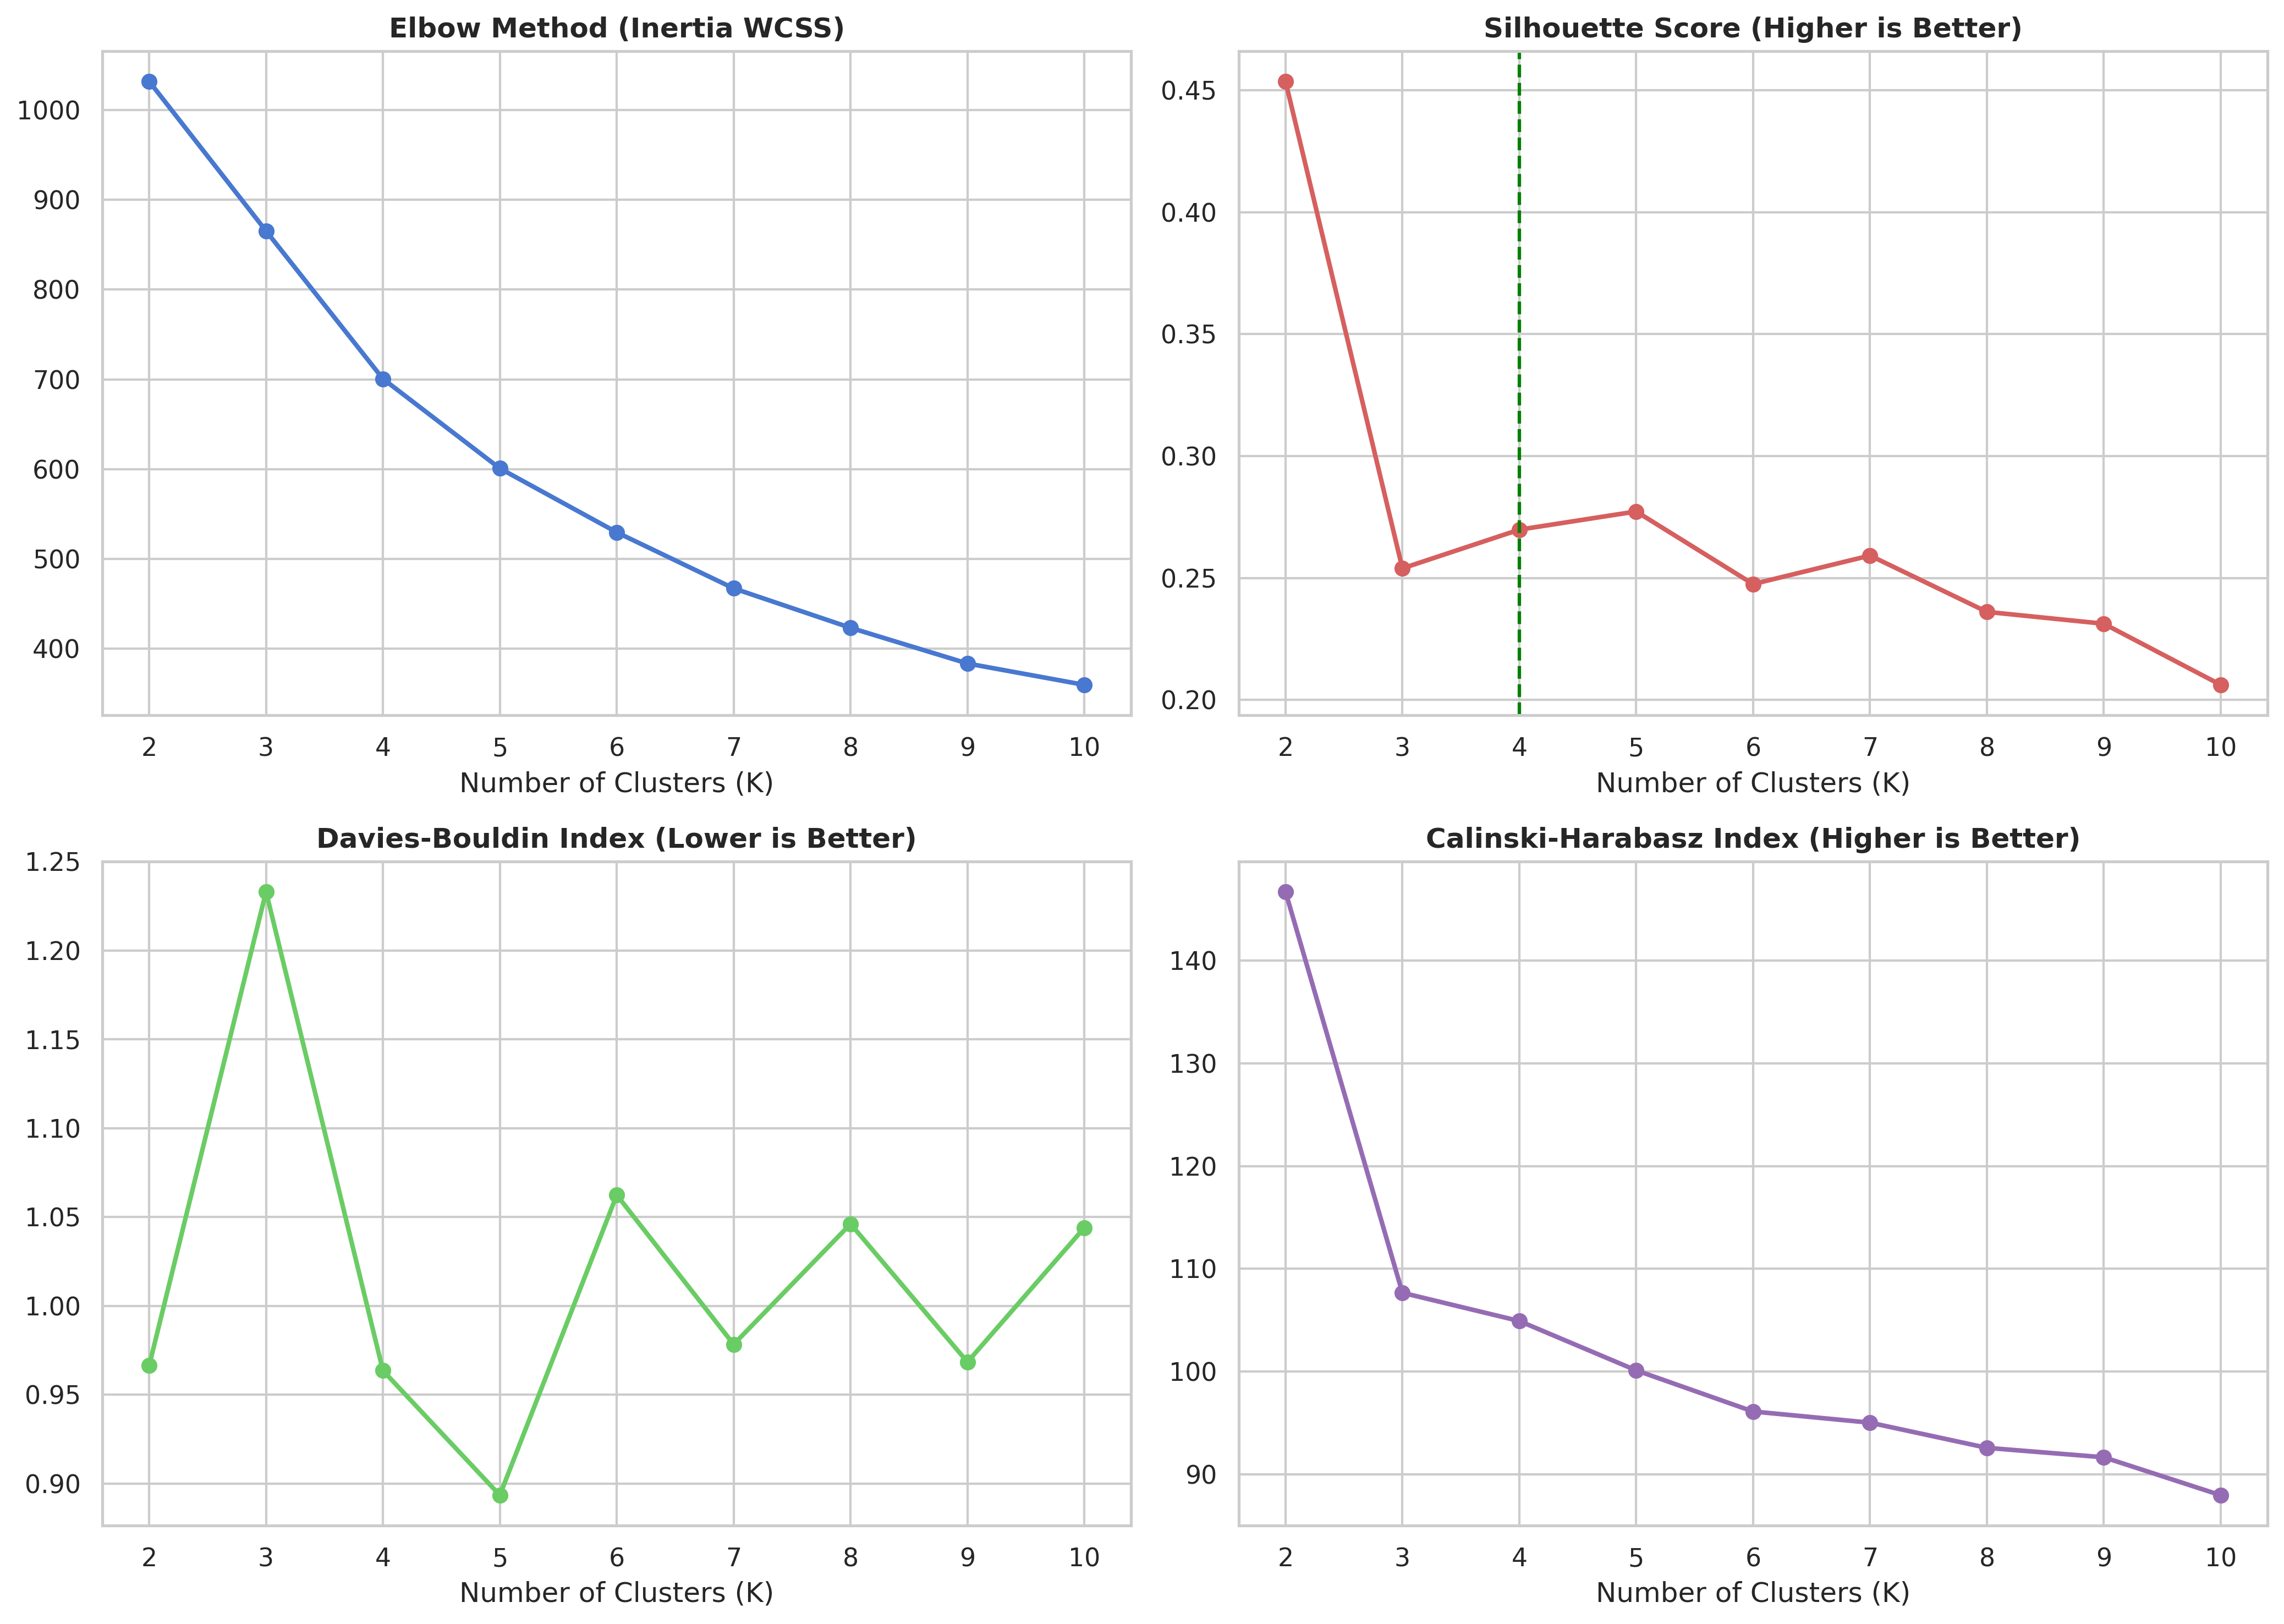

In [6]:
k_range = range(2, 11)
inertias, silhouette_scores, db_indices, ch_indices = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    db_indices.append(davies_bouldin_score(X_scaled, labels))
    ch_indices.append(calinski_harabasz_score(X_scaled, labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2)
axes[0, 0].set_title("Elbow Method (Inertia WCSS)", fontweight='bold')
axes[0, 0].set_xlabel("Number of Clusters (K)")

axes[0, 1].plot(k_range, silhouette_scores, 'ro-', linewidth=2)
axes[0, 1].set_title("Silhouette Score (Higher is Better)", fontweight='bold')
axes[0, 1].set_xlabel("Number of Clusters (K)")
axes[0, 1].axvline(x=4, color='green', linestyle='--', label='Selected K=4')

axes[1, 0].plot(k_range, db_indices, 'go-', linewidth=2)
axes[1, 0].set_title("Davies-Bouldin Index (Lower is Better)", fontweight='bold')
axes[1, 0].set_xlabel("Number of Clusters (K)")

axes[1, 1].plot(k_range, ch_indices, 'mo-', linewidth=2)
axes[1, 1].set_title("Calinski-Harabasz Index (Higher is Better)", fontweight='bold')
axes[1, 1].set_xlabel("Number of Clusters (K)")

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "clustering_evaluation_metrics.png"))
plt.show()


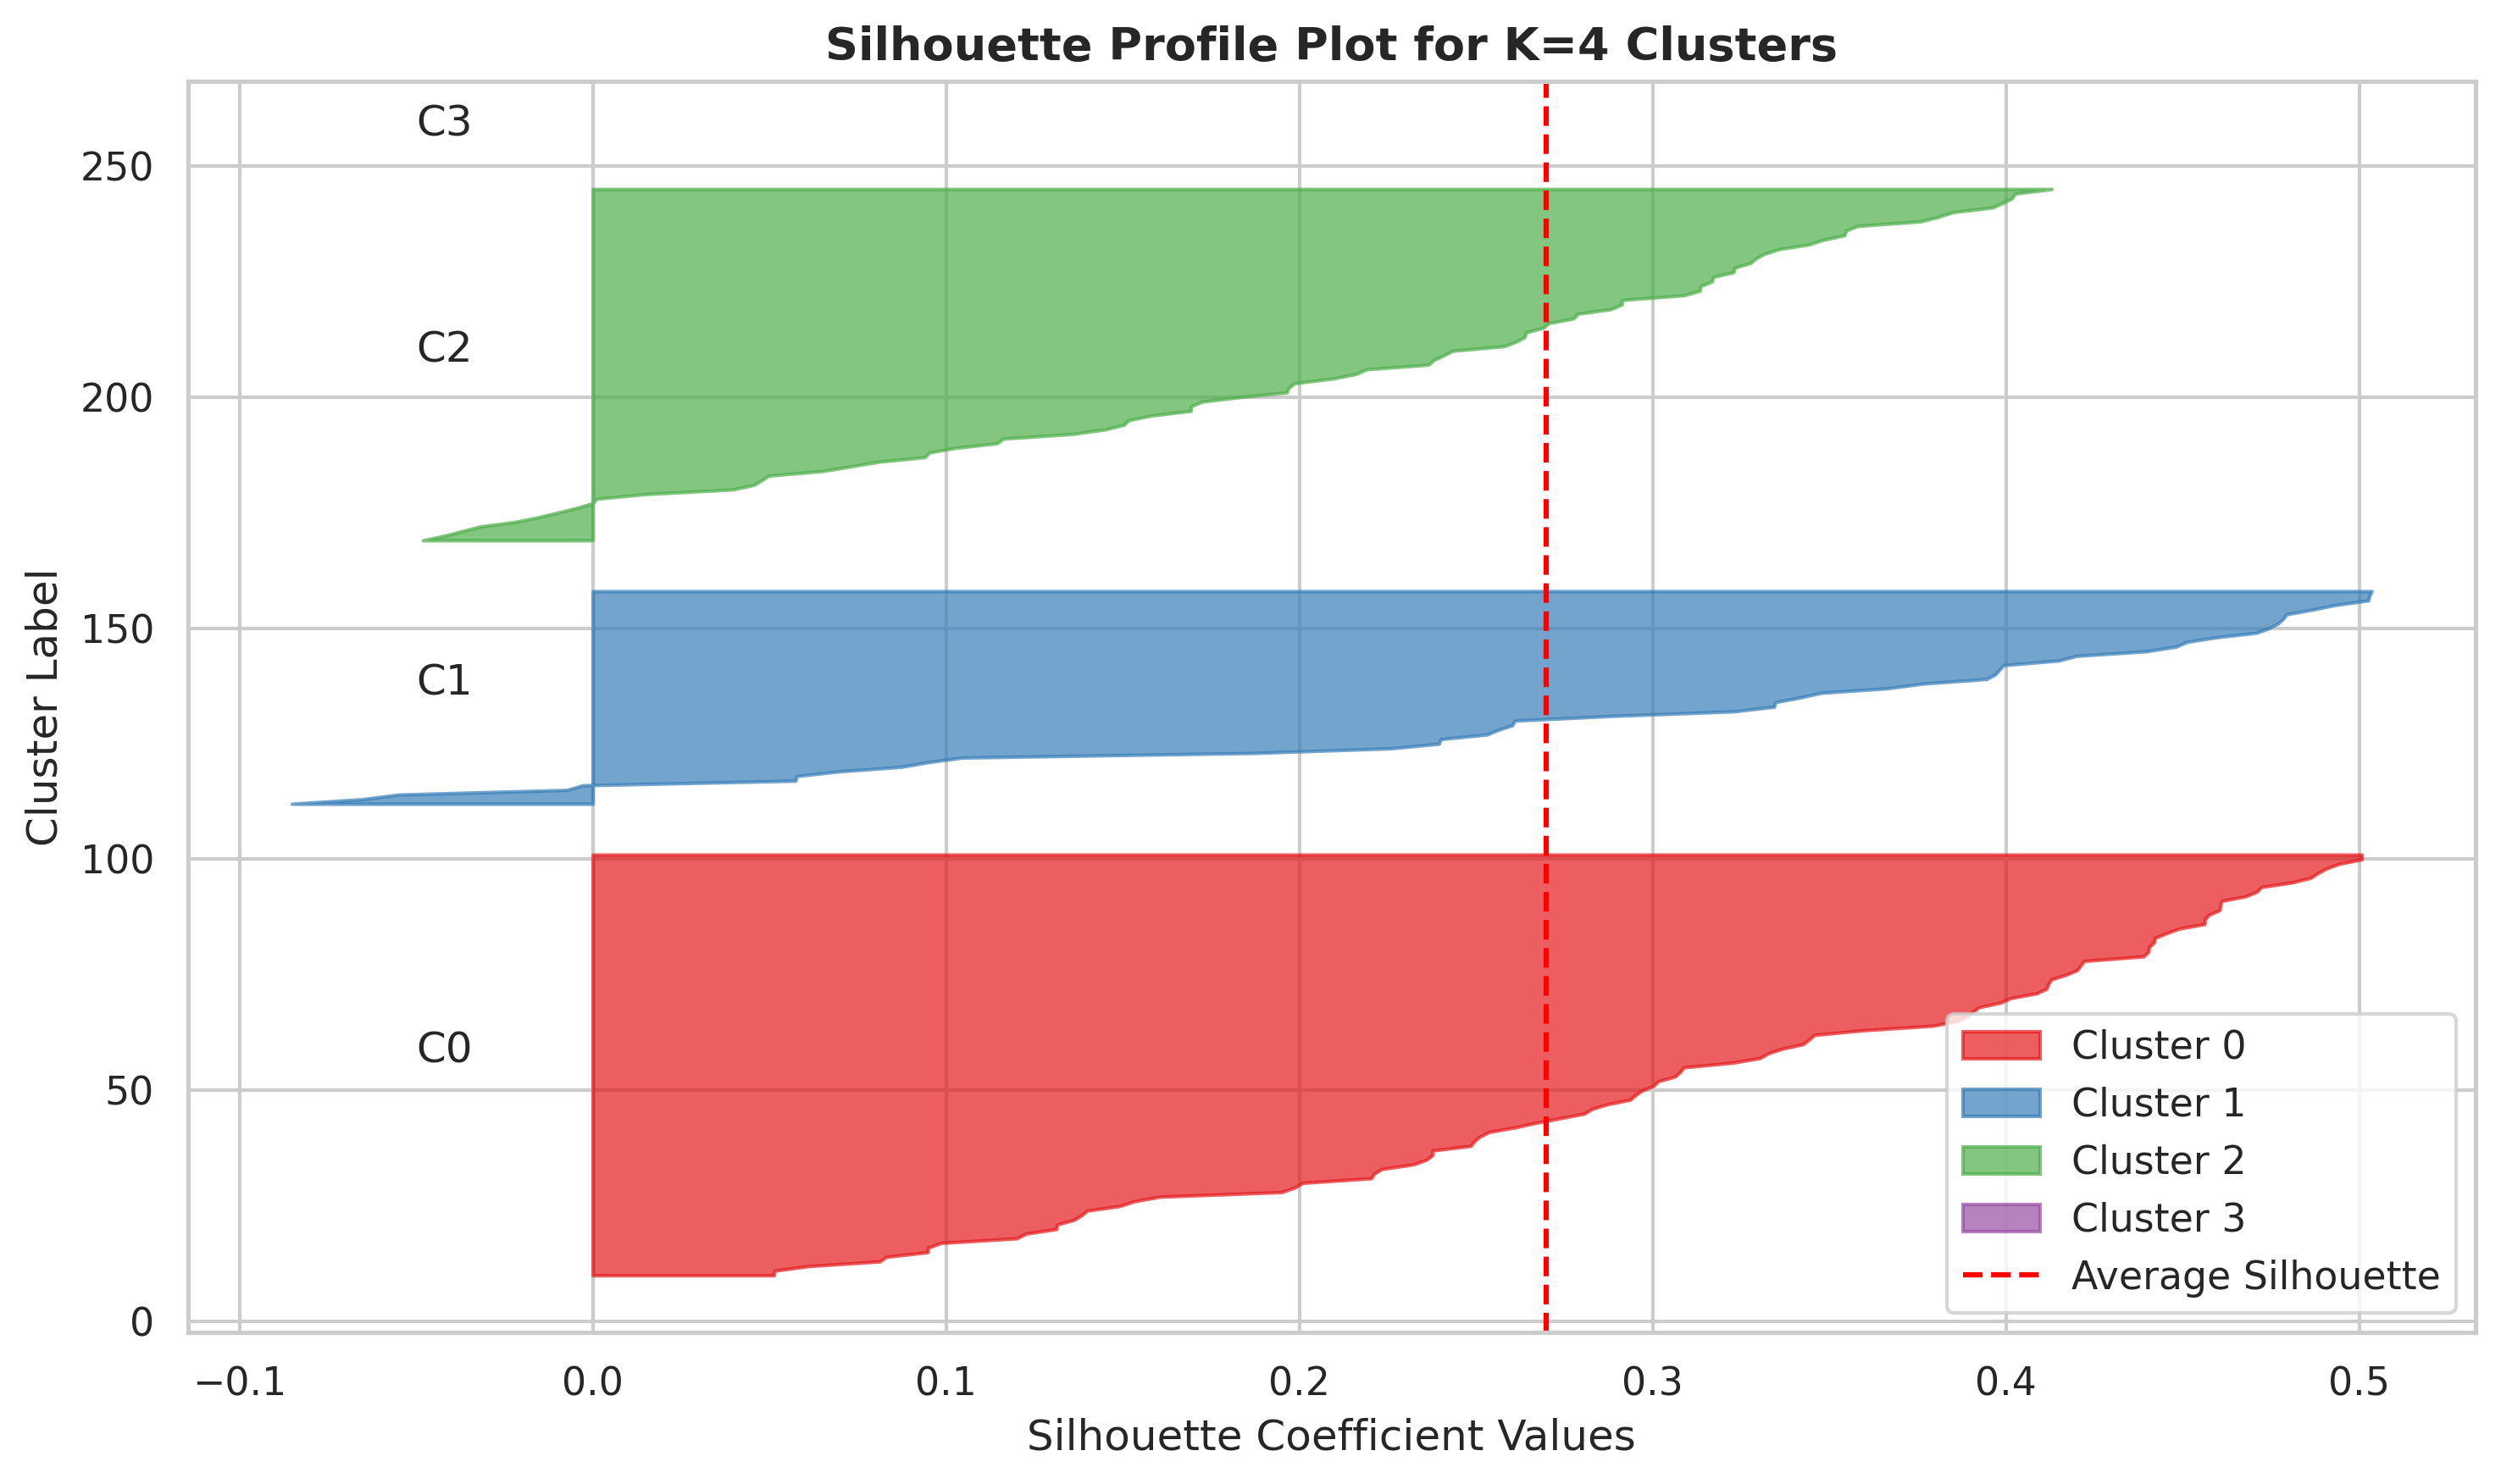

In [7]:
CHOSEN_K = 4
kmeans_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=30)
df_prep['Cluster'] = kmeans_final.fit_predict(X_scaled)

sample_silhouette_values = silhouette_samples(X_scaled, df_prep['Cluster'])

plt.figure(figsize=(10, 6))
y_lower = 10
colors = sns.color_palette("Set1", CHOSEN_K)

for i in range(CHOSEN_K):
    ith_cluster_sil_values = sample_silhouette_values[df_prep['Cluster'] == i]
    ith_cluster_sil_values.sort()
    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = colors[i]
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                     facecolor=color, edgecolor=color, alpha=0.7, label=f'Cluster {i}')
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, f"C{i}")
    y_lower = y_upper + 10

plt.axvline(x=silhouette_score(X_scaled, df_prep['Cluster']), color="red", linestyle="--", label="Average Silhouette")
plt.title(f"Silhouette Profile Plot for K={CHOSEN_K} Clusters", fontsize=13, fontweight='bold')
plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "silhouette_analysis_plot.png"))
plt.show()


---
## 7. Cluster Profiling & Output Interpretation Framework

We inspect feature means across the 4 clusters to establish developmental archetypes.


In [8]:
raw_means = df_prep.groupby('Cluster')[raw_features].mean()
display(raw_means.style.highlight_max(axis=0, color='lightgreen').highlight_min(axis=0, color='pink'))

# Export final dataframe
output_csv_path = os.path.join(data_dir, "final_country_development_clusters.csv")
df_prep.to_csv(output_csv_path, index=False)
print(f"Final dataset exported to: {output_csv_path}")


,GDP_per_capita,Life_Expectancy,Child_Mortality,Access_Electricity,Health_Expenditure_Pct,Inflation_Rate,Trade_Pct_GDP,Internet_Usage_Pct
Cluster,,,,,,,,
0,8290.518168,73.165568,19.595652,95.145109,5.682821,4.216859,78.545208,61.670652
1,1426.174108,61.903255,71.751064,47.395745,5.482745,7.798754,61.414980,21.621480
2,42094.073592,79.808643,6.986364,99.946753,8.218781,1.558039,119.269813,84.305652
3,2184.521554,61.060000,58.600000,46.700000,3.232682,255.304991,36.517868,26.588301


Final dataset exported to: ./data\final_country_development_clusters.csv
